# CITS5508: Assignment 1
**Name:** James Wigfield 

**Student ID:** 23334375 

Semester 1, 2026

## Part 1: Softmax Regression

### 1.1 Data Loading and Exploration
in this section the MNIST dataset is loaded from OpenML using scikit-learn's 'fetch_openml'.

I then explore the dataset by printing basic statistics and visualising examples from the dataset to understand what features and labels look like before any modelling. 


In [94]:
from sklearn.datasets import fetch_openml
import numpy as np

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

#### Display Dataset Statistics
Here, various statistics about the dataset has been printed. We can see that the total number of samples in the dataset is **70,000**, **784** features (which are simply 28 x 28 pixels in each image) and **10** classes (0-9 digits).

We can also see the class distribution of the dataset which ranges from roughly **9%** to **11%** showing that the dataset is relatively well balanced.

In [95]:
# Basic dataset info
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

# Class distribution
unique, counts = np.unique(y, return_counts=True)
print("\nClass distribution:")
for digit, count in zip(unique, counts):
    print(f"  Digit {int(digit)}: {count} samples ({100*count/len(y):.2f}%)")

# Data type and value ranges
# print(f"\nData type: {X.dtype}")
print(f"Value range: [{X.min():.1f}, {X.max():.1f}]")
print(f"Mean pixel value: {X.mean():.2f}")
print(f"Std pixel value: {X.std():.2f}")

# Missing values
print(f"Missing values: {np.isnan(X).sum()}")

Dataset shape: X=(70000, 784), y=(70000,)
Number of samples: 70000
Number of features: 784
Number of classes: 10
Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']

Class distribution:
  Digit 0: 6903 samples (9.86%)
  Digit 1: 7877 samples (11.25%)
  Digit 2: 6990 samples (9.99%)
  Digit 3: 7141 samples (10.20%)
  Digit 4: 6824 samples (9.75%)
  Digit 5: 6313 samples (9.02%)
  Digit 6: 6876 samples (9.82%)
  Digit 7: 7293 samples (10.42%)
  Digit 8: 6825 samples (9.75%)
  Digit 9: 6958 samples (9.94%)
Value range: [0.0, 255.0]
Mean pixel value: 33.39
Std pixel value: 78.65
Missing values: 0


In [92]:
# import matplotlib.pyplot as plt

# # Display the first 10 images and their labels
# fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# for i, ax in enumerate(axes.flatten()):
#     ax.imshow(X[i].reshape(28, 28), cmap='gray')
#     ax.set_title(f"Label: {y[i]}")
#     ax.axis('off')
    
# plt.tight_layout()
# plt.show()

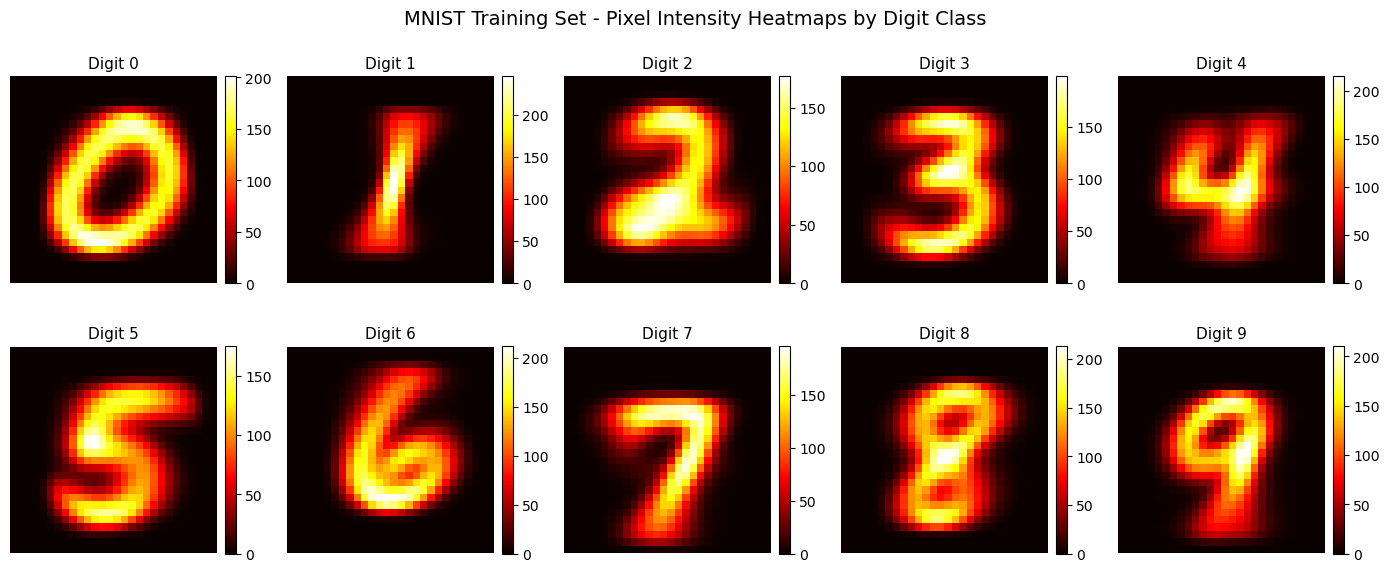

In [99]:
import matplotlib.pyplot as plt

# Display heatmaps for each digit class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for digit in range(10):
    # Find all indices where the label matches this digit
    indices = np.where(y_train == str(digit))[0]
    
    # Extract all images for this digit and reshape
    digit_images = X_train[indices].reshape(len(indices), 28, 28)
    
    # Average all images for this digit to create heatmap
    heatmap = np.mean(digit_images, axis=0)
    
    # Display as heatmap
    ax = axes[digit]
    im = ax.imshow(heatmap, cmap='hot')
    ax.set_title(f"Digit {digit}", fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('MNIST Training Set - Pixel Intensity Heatmaps by Digit Class', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


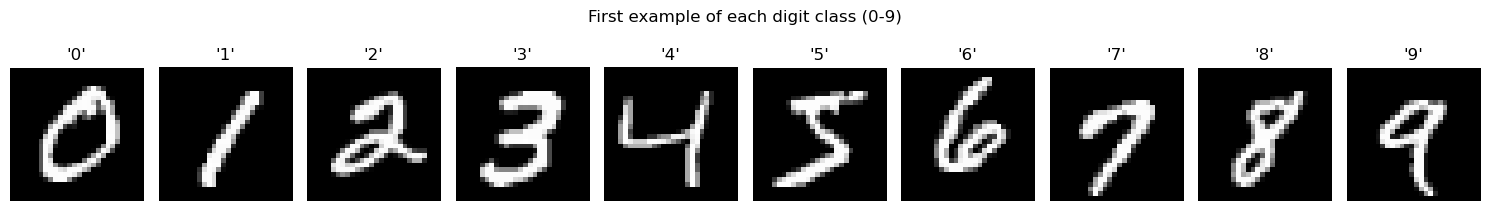

In [96]:
import matplotlib.pyplot as plt

# Display the first example of each digit class (0–9)
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for digit in range(10):
    idx = np.where(y == str(digit))[0][0]
    axes[digit].imshow(X[idx].reshape(28, 28), cmap='gray')
    axes[digit].set_title(f"'{digit}'")
    axes[digit].axis('off')
plt.suptitle('First example of each digit class (0-9)', y=1.05)
plt.tight_layout()
plt.show()

#### Dataset Description
The MNIST dataset is a famous dataset consisting of 70,000 greyscale images of handwritten digits (0-9). Some examples of what these images look like are displayed from the above code block (these are just the first 10 digits in the datset, not not ordered from 0 to 9). Each image is 28 x 28 pixels which have been flattened into a row of 784 features. Each of these features is simply a greyscale pixel intensity which is reporesented as an integer between 0 and 255. The labels are the digit that the image represets which are stored as strings '0' - '9'. 

### 1.2 Data Splitting
Here the MNIST samples have been split into three subsets:
- **Training set (70%)**: Used to learn the model parameters (weights) during fitting.  
- **Validation set (15%)**: Used during development to tune hyperparameters and monitor performance (e.g. early stopping) without touching test data.  
- **Test set (15%)**: Held out until final evaluation to provide an unbiased estimate of how well the model generalises to unseen data.

In [73]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the 30% evenly (15% val and test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation set: X_val={X_val.shape}, y_val={y_val.shape}")

Training set: X_train=(49000, 784), y_train=(49000,)
Validation set: X_val=(10500, 784), y_val=(10500,)


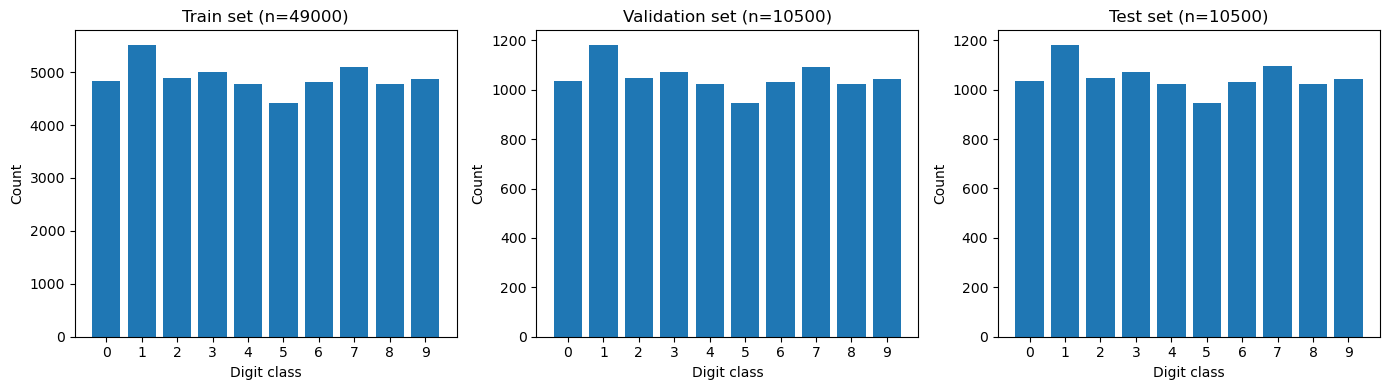

In [74]:
# Display Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]

for ax, (name, labels) in zip(axes, splits):
    classes, counts = np.unique(labels, return_counts=True)
    ax.bar(classes, counts)
    ax.set_title(f'{name} set (n={len(labels)})')
    ax.set_xlabel('Digit class')
    ax.set_ylabel('Count')
    ax.set_xticks(classes)

plt.tight_layout()
plt.show()

#### Stratification Justification
The dataset has been split into a Training (70%), Validation(15%) and Test (15%) set using *train_test_split*, however, this function doesn't support 3 way splits so it has been done in 2 stages. First split was a 70% train and 30% temporary split, then the temporary split was split evenly to give a 15% validation and 15% test set. 

As we can see from the class distribution from each set, there doesn't appear to be any major class imballance with only the digit class '1' appearing a few hundred more times. **actually compare to the average**.  

**Stratification:** I set ```stratify=y``` to ensure that each split has the same class proportions as the whole dataset. Without stratification, since 1 is the most frequent class in MNIST (11.25%) and 5 is the least frequent (9.02%), these classes would likely be over/under represented in a completely random unstratified split.

### 1.3 Softmax Regression Implementation

Here we implement softmax regression from scratch using only NumPy. The model uses **mini-batch gradient descent** to minimise the cross-entropy loss, and applies **early stopping** based on the validation loss to prevent overfitting.

Before training, pixel values are normalised from [0, 255] to [0, 1] by dividing by 255. This is important since without scaling, the large raw pixel values produce extremely large dot products, causing numerical overflow in the softmax exponentials and making gradient descent would be unstable.

The core mathematics follows the assignment formulas directly:
- The softmax function converts raw class scores into probabilities
- The cross-entropy loss measures how far predicted probabilities are from the true one-hot labels
- The gradient update nudges the weight matrix in the direction that reduces loss

In [79]:
# normalise pixel values to [0, 1]
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

# softmax regression from scratch - no sklearn allowed for the model itself
class SoftmaxRegression:

    def __init__(self, lr=0.1, max_epochs=1000, batch_size=256, patience=50,
                 print_every=100, random_state=42):
        self.lr = lr
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.print_every = print_every
        self.rng = np.random.default_rng(random_state)

    def _add_bias(self, X):
        # prepend a column of 1s so the bias is absorbed into W
        return np.c_[np.ones(X.shape[0]), X]

    def _softmax(self, Z):
        # subtract row max first to stop exp() overflowing (numerically stable trick)
        Z_shift = Z - Z.max(axis=1, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / exp_Z.sum(axis=1, keepdims=True)

    def _one_hot(self, y):
        # e.g. label '3' -> [0,0,0,1,0,0,0,0,0,0]
        indices = np.array([self.class_to_idx_[label] for label in y])
        Y = np.zeros((len(y), len(self.classes_)))
        Y[np.arange(len(y)), indices] = 1
        return Y

    def _cross_entropy(self, X_b, Y_oh):
        P = self._softmax(X_b @ self.W_)
        return -np.mean(np.sum(Y_oh * np.log(P + 1e-15), axis=1))

    def fit(self, X, y, X_val, y_val):
        self.classes_ = np.unique(y)
        self.class_to_idx_ = {c: i for i, c in enumerate(self.classes_)}

        X_b = self._add_bias(X)
        X_val_b = self._add_bias(X_val)
        Y_oh = self._one_hot(y)
        Y_val = self._one_hot(y_val)

        m, n = X_b.shape
        K = len(self.classes_)

        self.W_ = np.zeros((n, K))
        self.train_losses_ = []
        self.val_losses_ = []

        best_val_loss = np.inf
        best_W = self.W_.copy()
        no_improve = 0

        if self.print_every:
            w = len(str(self.max_epochs))
            print(f"{'Epoch':>{w + 7}}  {'train loss':>10}  {'val loss':>10}")
            print("-" * (w + 34))

        for epoch in range(self.max_epochs):
            # shuffle training data each epoch so mini-batches are different
            perm = self.rng.permutation(m)
            X_shuf = X_b[perm]
            Y_shuf = Y_oh[perm]

            for start in range(0, m, self.batch_size):
                Xb = X_shuf[start : start + self.batch_size]
                Yb = Y_shuf[start : start + self.batch_size]
                P = self._softmax(Xb @ self.W_)
                # vectorised gradient: (1/m) * X^T(P - Y) from the assignment formula
                grad = Xb.T @ (P - Yb) / len(Xb)
                self.W_ -= self.lr * grad

            train_loss = self._cross_entropy(X_b, Y_oh)
            val_loss = self._cross_entropy(X_val_b, Y_val)
            self.train_losses_.append(train_loss)
            self.val_losses_.append(val_loss)

            improved = val_loss < best_val_loss
            if improved:
                best_val_loss = val_loss
                best_W = self.W_.copy()
                no_improve = 0
            else:
                no_improve += 1

            if self.print_every and (epoch + 1) % self.print_every == 0:
                marker = " <-- best" if improved else ""
                print(f"  Epoch {epoch + 1:>{w}}/{self.max_epochs}  "
                      f"{train_loss:>10.4f}  {val_loss:>10.4f}{marker}")

            # stop early if val loss hasn't improved in 'patience' epochs
            if no_improve >= self.patience:
                print(f"Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.4f})")
                break

        # restore best weights found during training
        self.W_ = best_W
        self.n_epochs_run_ = len(self.train_losses_)
        return self

    def predict_proba(self, X):
        return self._softmax(self._add_bias(X) @ self.W_)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


In [80]:
model = SoftmaxRegression(lr=0.1, max_epochs=200, batch_size=256, patience=15, random_state=42)
model.fit(X_train_norm, y_train, X_val_norm, y_val)

train_acc = np.mean(model.predict(X_train_norm) == y_train)
val_acc = np.mean(model.predict(X_val_norm) == y_val)
print(f"Epochs run: {model.n_epochs_run_}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")


     Epoch  train loss    val loss
-------------------------------------
  Epoch 100/200      0.2494      0.2957
Early stopping at epoch 146 (best val loss: 0.2933)
Epochs run: 146
Train accuracy: 0.9330
Validation accuracy: 0.9199


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(model.train_losses_) + 1)

ax.plot(epochs, model.train_losses_, label='Training loss', linewidth=2)
ax.plot(epochs, model.val_losses_, label='Validation loss', linewidth=2, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Softmax Regression - Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


#### Training Observations:
Answer Task 4b here: Comment on the loss curves. Did the model converge? When did early stopping kick in? Is this what you expected?

In the graph of cross entropy loss vs Epochs we can see that both the training and validation loss seem to converge at a consistent rate. There is likely some slight overfitting since the validation loss flattens before the training loss but since the difference is only about 0.05 this is a healthy small gap. 

### 1.4 Scikit-Learn Logistic Regression Comparison

To validate our from-scratch implementation we compare it against scikit-learn's `LogisticRegression`, which uses the **L-BFGS** optimiser — a quasi-Newton second-order method that converges far more efficiently than our gradient descent. We set `penalty=None` to disable regularisation as required by the assignment.

The comparison covers:
- Accuracy on training and test sets for both models
- Confusion matrices showing per-class error patterns on the test set
- Per-class precision, recall, and F1-score via `classification_report`

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# no regularisation (penalty=None) so comparison with our custom model is fair
sklearn_model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42)
sklearn_model.fit(X_train_norm, y_train)

print(f"{'Model':<30}  {'Train acc':>10}  {'Test acc':>10}")
print("-" * 56)
for name, clf in [('Custom Softmax Regression', model), ('sklearn LogisticRegression', sklearn_model)]:
    tr = accuracy_score(y_train, clf.predict(X_train_norm))
    te = accuracy_score(y_test, clf.predict(X_test_norm))
    print(f"{name:<30}  {tr:>10.4f}  {te:>10.4f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, model.predict(X_test_norm),
    ax=axes[0], colorbar=False
)
axes[0].set_title('Custom Softmax Regression (test set)')

ConfusionMatrixDisplay.from_predictions(
    y_test, sklearn_model.predict(X_test_norm),
    ax=axes[1], colorbar=False
)
axes[1].set_title('sklearn LogisticRegression (test set)')

plt.tight_layout()
plt.show()


In [ ]:
print("=== Custom Softmax Regression - Test Set ===")
print(classification_report(y_test, model.predict(X_test_norm), digits=4))

print("=== sklearn LogisticRegression - Test Set ===")
print(classification_report(y_test, sklearn_model.predict(X_test_norm), digits=4))


#### Model Comparison & Evaluation

*(Write your commentary here in your own words. Use the printed metrics and confusion matrices above as evidence. Some questions to address:)*

- *How close are the two models in accuracy? Is the gap larger on train or test?*
- *Which digit pairs cause the most confusion in both models — are they the same pairs?*
- *Did the sklearn model improve noticeably on the hard classes (e.g. 4 vs 9, 3 vs 8)?*
- *Is the result what you expected given that both models are fundamentally linear classifiers?*
- *What does the train vs test accuracy gap tell you about overfitting for each model?*

## Part 2: Support Vector Machine Regression

### 2.1 Dataset Generation

We generate synthetic polynomial datasets of the form:

$$y = \sum_{k=0}^{n} a_k x^k + \varepsilon$$

where $x \in [-3, 3]$, coefficients $a_k \sim \mathcal{U}(0, 1)$, and noise $\varepsilon \sim \mathcal{N}(0, 1)$.

The function `generate_polynomial_dataset(degree, n_samples)` encapsulates this generation process. We then verify it visually using demo plots for degree = 1, 2, and 3, before generating the three full datasets (linear, quadratic, cubic) with train/test splits for use in the SVR experiments.

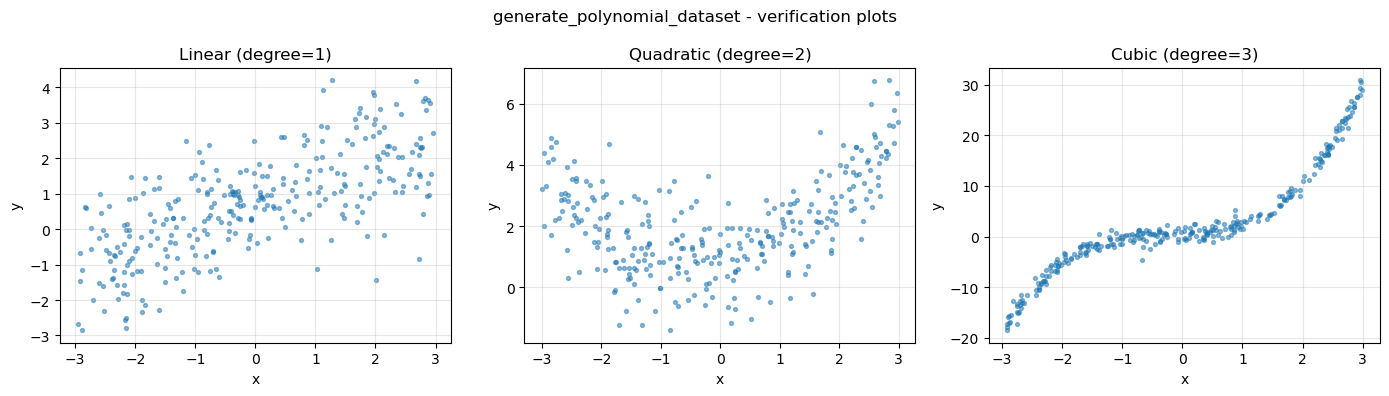

In [85]:
def generate_polynomial_dataset(degree, n_samples, random_state=42):
    rng = np.random.default_rng(random_state)
    x = rng.uniform(-3, 3, n_samples)
    # random coefficients a_0 ... a_degree, each from U(0,1)
    a = rng.uniform(0, 1, degree + 1)
    # y = sum(a_k * x^k) + noise, where noise ~ N(0,1)
    y = sum(a[k] * x**k for k in range(degree + 1)) + rng.standard_normal(n_samples)
    return x.reshape(-1, 1), y

# quick sanity check - plot each degree to verify the function looks right
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [('Linear (degree=1)', 1, 10), ('Quadratic (degree=2)', 2, 20), ('Cubic (degree=3)', 3, 30)]

for ax, (title, degree, seed) in zip(axes, configs):
    X_demo, y_demo = generate_polynomial_dataset(degree, n_samples=300, random_state=seed)
    ax.scatter(X_demo, y_demo, s=8, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)

plt.suptitle('generate_polynomial_dataset - verification plots')
plt.tight_layout()
plt.show()


In [86]:
# different seeds so each dataset has independent x values and coefficients
X_lin, y_lin = generate_polynomial_dataset(degree=1, n_samples=1000, random_state=10)
X_quad, y_quad = generate_polynomial_dataset(degree=2, n_samples=1000, random_state=20)
X_cub, y_cub = generate_polynomial_dataset(degree=3, n_samples=1000, random_state=30)

# 80/20 train/test splits
X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)
X_quad_train, X_quad_test, y_quad_train, y_quad_test = train_test_split(X_quad, y_quad, test_size=0.2, random_state=42)
X_cub_train, X_cub_test, y_cub_train, y_cub_test = train_test_split(X_cub, y_cub, test_size=0.2, random_state=42)

# summary stats per dataset
print(f"{'Dataset':<12}  {'Split':<6}  {'n':>5}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}")
print("-" * 62)
for name, y_tr, y_te in [
    ('Linear', y_lin_train, y_lin_test),
    ('Quadratic', y_quad_train, y_quad_test),
    ('Cubic', y_cub_train, y_cub_test),
]:
    for split, y in [('train', y_tr), ('test', y_te)]:
        print(f"{name:<12}  {split:<6}  {len(y):>5}  {y.mean():>8.3f}  {y.std():>8.3f}  {y.min():>8.3f}  {y.max():>8.3f}")


Dataset       Split       n      mean       std       min       max
--------------------------------------------------------------
Linear        train     800     0.264     1.886    -4.306     5.019
Linear        test      200     0.477     1.841    -3.590     5.014
Quadratic     train     800     0.367     1.050    -3.417     3.173
Quadratic     test      200     0.494     1.049    -2.432     3.278
Cubic         train     800     2.046     9.519   -23.494    26.785
Cubic         test      200     3.021    10.099   -20.583    27.232


### 2.2 SVR with Different Kernels

We fit `sklearn.svm.SVR` models using three kernels — `linear`, `poly`, and `rbf` — to each of the three synthetic datasets (linear, quadratic, and cubic). Each model is wrapped in a `make_pipeline` with `StandardScaler` since SVR is sensitive to input scale.

The 3x3 grid below shows the fitted regression curve against training and test data for all nine kernel x dataset combinations. Test-set R² is annotated on each subplot and summarised in a table below the figure.

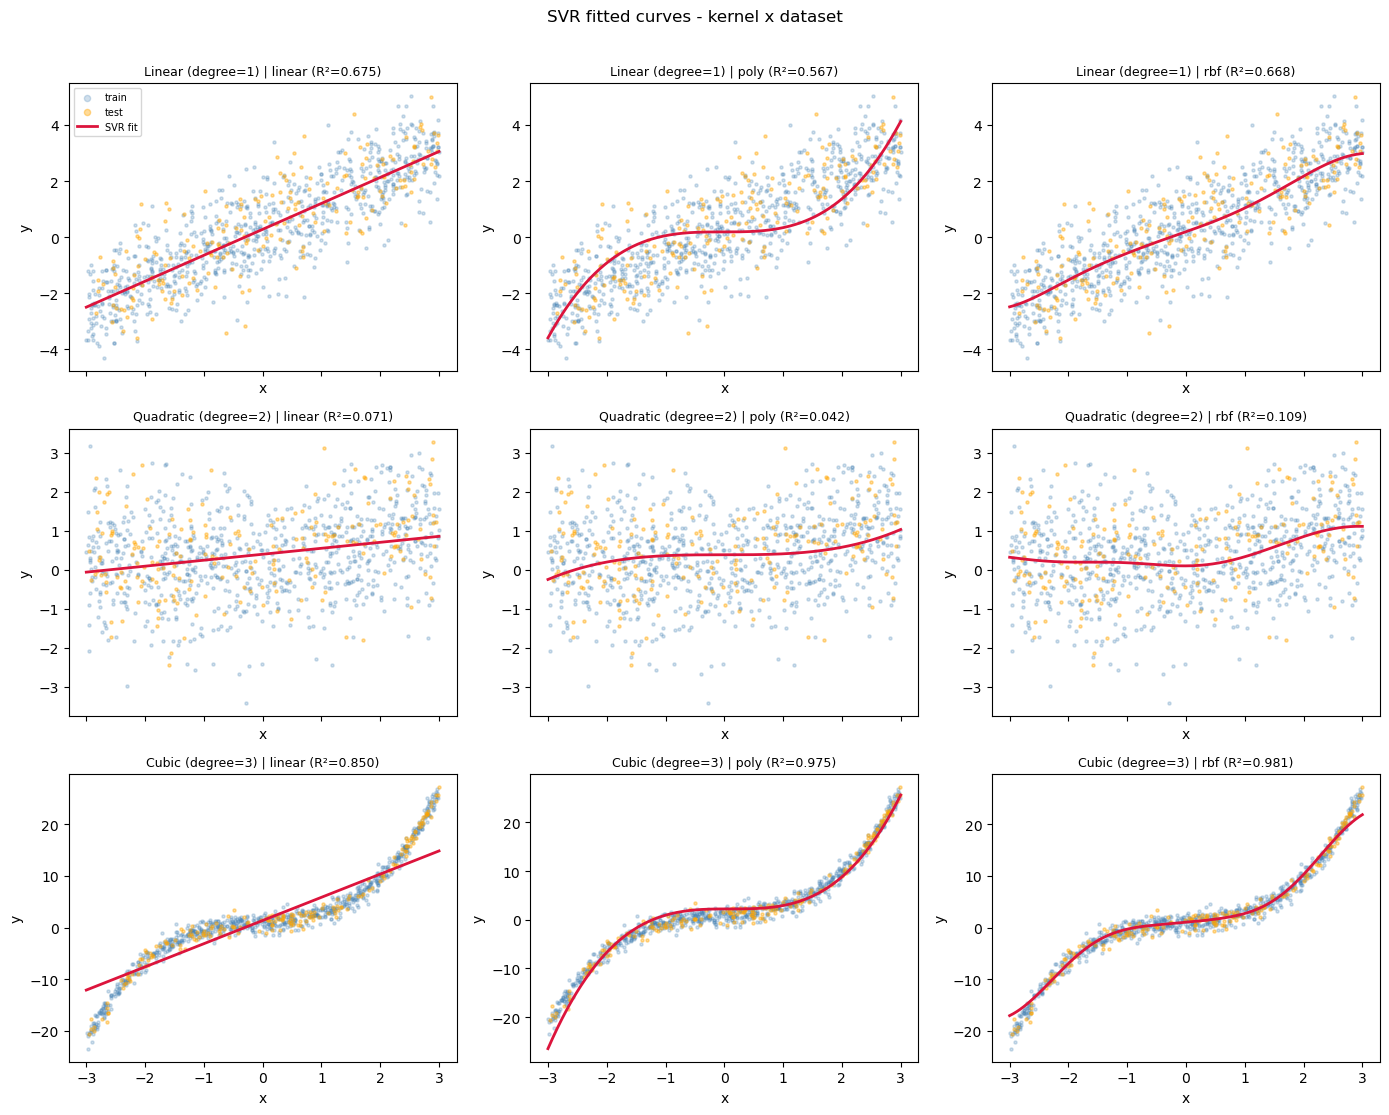

Dataset                    kernel=linear     kernel=poly      kernel=rbf
------------------------------------------------------------------------
Linear (degree=1)                 0.6753          0.5665          0.6676
Quadratic (degree=2)              0.0707          0.0421          0.1087
Cubic (degree=3)                  0.8497          0.9746          0.9806


In [87]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

kernels = ['linear', 'poly', 'rbf']
datasets = [
    ('Linear (degree=1)', X_lin_train, y_lin_train, X_lin_test, y_lin_test),
    ('Quadratic (degree=2)', X_quad_train, y_quad_train, X_quad_test, y_quad_test),
    ('Cubic (degree=3)', X_cub_train, y_cub_train, X_cub_test, y_cub_test),
]

x_grid = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(3, 3, figsize=(14, 11), sharex=True)
svr_models = {}

for row, (name, X_tr, y_tr, X_te, y_te) in enumerate(datasets):
    for col, kernel in enumerate(kernels):
        ax = axes[row, col]
        # SVR is sensitive to feature scale, so StandardScaler is important
        svr = make_pipeline(StandardScaler(), SVR(kernel=kernel))
        svr.fit(X_tr, y_tr)
        svr_models[(name, kernel)] = svr

        r2 = svr.score(X_te, y_te)
        ax.scatter(X_tr, y_tr, s=5, alpha=0.25, color='steelblue', label='train')
        ax.scatter(X_te, y_te, s=5, alpha=0.4, color='orange', label='test')
        ax.plot(x_grid, svr.predict(x_grid), color='crimson', linewidth=2, label='SVR fit')
        ax.set_title(f'{name} | {kernel} (R²={r2:.3f})', fontsize=9)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        if row == 0 and col == 0:
            ax.legend(fontsize=7, markerscale=2)

plt.suptitle('SVR fitted curves - kernel x dataset', y=1.01)
plt.tight_layout()
plt.show()

# R-squared summary table
header = f"{'Dataset':<24}  " + '  '.join(f"{'kernel='+k:>14}" for k in kernels)
print(header)
print('-' * len(header))
for name, X_tr, y_tr, X_te, y_te in datasets:
    scores = [f"{svr_models[(name, k)].score(X_te, y_te):>14.4f}" for k in kernels]
    print(f"{name:<24}  " + '  '.join(scores))


#### Kernel Performance Analysis

*(Write your commentary here in your own words. Use the plots and R² table above as evidence. Some questions to address:)*

- *Linear kernel on linear data: did it fit well? What does a good R² look like here?*
- *Linear kernel on quadratic/cubic data: did it underfit? What does the fitted curve look like vs the data shape?*
- *Poly kernel: did it handle the higher-degree datasets better? What is the default degree and does it matter?*
- *RBF kernel: how did it perform across all three datasets? Is it the most flexible? Any signs of overfitting on the simpler datasets?*
- *Which kernel generalises best across all dataset types, and why?*

### 2.3 Hyperparameter Tuning via Grid Search

We use `GridSearchCV` with 5-fold cross-validation to search over three SVR hyperparameters on the **cubic dataset** — the most challenging of the three.

The hyperparameters and their candidate values are:

| Hyperparameter | Values | What it controls |
|---|---|---|
| `kernel` | `poly`, `rbf` | How the input space is transformed |
| `C` | `1`, `100` | Regularisation — how much to penalise errors outside the ε-tube |
| `epsilon` | `0.1`, `0.5` | Width of the ε-tube; points inside incur no loss |

2 values × 2 values × 2 values = **8 combinations**, each evaluated with **5-fold CV** = **40 models** fitted in total.

In [88]:
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd

# grid over kernel type, regularisation C, and epsilon (tube width)
# note: pipeline params use double underscore prefix, e.g. svr__C
param_grid = {
    'svr__kernel': ['poly', 'rbf'],
    'svr__C': [1, 100],
    'svr__epsilon': [0.1, 0.5],
}

pipe = make_pipeline(StandardScaler(), SVR())
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipe, param_grid,
    cv=kf, scoring='r2',
    refit=True, n_jobs=-1,
)
grid_search.fit(X_cub_train, y_cub_train)

n_combos = len(grid_search.cv_results_['params'])
print(f'Hyperparameters: {list(param_grid.keys())}')
print(f'Combinations:    {n_combos}')
print(f'Folds:           5')
print(f'Total models:    {n_combos * 5}')
print(f'Best params:     {grid_search.best_params_}')
print(f'Best CV R²:      {grid_search.best_score_:.4f}')

# full results sorted by rank
cols = ['param_svr__kernel', 'param_svr__C', 'param_svr__epsilon',
        'mean_test_score', 'std_test_score', 'rank_test_score']
results_df = (pd.DataFrame(grid_search.cv_results_)[cols]
              .rename(columns={
                  'param_svr__kernel': 'kernel',
                  'param_svr__C': 'C',
                  'param_svr__epsilon': 'epsilon',
                  'mean_test_score': 'mean R²',
                  'std_test_score': 'std R²',
                  'rank_test_score': 'rank',
              })
              .sort_values('rank')
              .reset_index(drop=True))
print()
print(results_df.to_string(index=False, float_format='{:.4f}'.format))


Hyperparameters: ['svr__kernel', 'svr__C', 'svr__epsilon']
Combinations:    8
Folds:           5
Total models:    40
Best params:     {'svr__C': 100, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf'}
Best CV R²:      0.9885

kernel   C  epsilon  mean R²  std R²  rank
   rbf 100   0.1000   0.9885  0.0021     1
   rbf 100   0.5000   0.9884  0.0020     2
   rbf   1   0.1000   0.9759  0.0020     3
   rbf   1   0.5000   0.9756  0.0022     4
  poly   1   0.5000   0.9661  0.0090     5
  poly 100   0.5000   0.9660  0.0091     6
  poly   1   0.1000   0.9656  0.0093     7
  poly 100   0.1000   0.9653  0.0095     8


#### Grid Search Results

*(Write your commentary here in your own words. Cover:)*

- *Which three hyperparameters did you choose and why each one is meaningful for SVR?*
- *How many total models were fitted (combinations × folds)?*
- *What were the best hyperparameters found? Was the result surprising?*
- *Does the best CV R² suggest the model is fitting the cubic data well?*
- *What does the std R² column tell you about result stability across folds?*

### 2.4 Optimal Model Evaluation

We evaluate the best model found by the grid search on the held-out test set.
This gives an unbiased estimate of performance on data the model has never seen —
neither during training nor during cross-validation.

Best params:    {'svr__C': 100, 'svr__epsilon': 0.1, 'svr__kernel': 'rbf'}
CV R² (train):  0.9885
Test R²:        0.9903


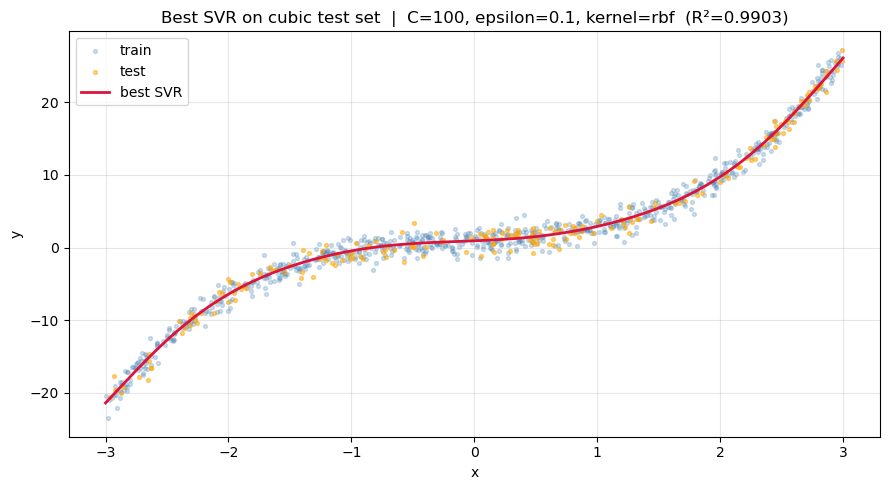

In [89]:
best_model = grid_search.best_estimator_
test_r2 = best_model.score(X_cub_test, y_cub_test)

print(f'Best params:    {grid_search.best_params_}')
print(f'CV R² (train):  {grid_search.best_score_:.4f}')
print(f'Test R²:        {test_r2:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_cub_train, y_cub_train, s=8, alpha=0.25, color='steelblue', label='train')
ax.scatter(X_cub_test, y_cub_test, s=8, alpha=0.5, color='orange', label='test')
ax.plot(x_grid, best_model.predict(x_grid), color='crimson', linewidth=2, label='best SVR')
params_str = ', '.join(f'{k.replace("svr__","")}={v}' for k, v in grid_search.best_params_.items())
ax.set_title('Best SVR on cubic test set  |  ' + params_str + f'  (R²={test_r2:.4f})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Final Conclusion 